In [3]:
import pandas as pd
data = pd.read_csv(r"C:\Users\Dyuthi\ML_Project\train.csv")
print(data.head())

   id  MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0   0                 5                   8                5              8   
1   1                 6                   7                4              4   
2   2                 6                   5                6              7   
3   3                 3                   4                6              5   
4   4                 5                   3                2              6   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             6              4            4          3                      3   
1             8              8            3          5                      4   
2             3              7            1          5                      4   
3             4              8            4          7                      6   
4             4              4            3          3                      3   

   ...  DrainageSystems  CoastalVulner

In [4]:
data = data.drop("id", axis=1)
X = data.drop("FloodProbability", axis=1)
y = data["FloodProbability"]

print(X.shape, y.shape)

(1117957, 20) (1117957,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(894365, 20) (223592, 20)


In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.02448631346380908
R2 Score: 0.6548426804889196


In [1]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Dyuthi\ML_Project\train.csv")

print(data.shape)

(1117957, 22)


In [2]:
# Reduce to 100k rows
data = data.sample(n=100000, random_state=42)

print(data.shape)

(100000, 22)


In [3]:
# Drop useless column
data = data.drop("id", axis=1)

In [4]:
X = data.drop("FloodProbability", axis=1)
y = data["FloodProbability"]

print(X.shape, y.shape)

(100000, 20) (100000,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(80000, 20) (20000, 20)


In [6]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.029414382890994635
R2 Score: 0.5117228167328178


In [9]:
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

               Feature  Importance
7            Siltation    0.054662
6          DamsQuality    0.054140
5        ClimateChange    0.053935
3        Deforestation    0.052963
1   TopographyDrainage    0.052383
2      RiverManagement    0.052146
0     MonsoonIntensity    0.051701
9        Encroachments    0.051577
16     PopulationScore    0.050864
13          Landslides    0.050142


In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.026572437491481367
R2: 0.6041056913045979


In [12]:
def get_risk_level(p):
    if p > 0.7:
        return "High Risk"
    elif p > 0.4:
        return "Moderate Risk"
    else:
        return "Low Risk"

In [14]:
risk_levels = [get_risk_level(p) for p in y_pred]

# Show sample
for i in range(10):
    print("Prediction:", y_pred[i], "→", risk_levels[i])

Prediction: 0.503270685548202 → Moderate Risk
Prediction: 0.4817907330391254 → Moderate Risk
Prediction: 0.4943143751901928 → Moderate Risk
Prediction: 0.4882224451988521 → Moderate Risk
Prediction: 0.49823704290559084 → Moderate Risk
Prediction: 0.5116995667529628 → Moderate Risk
Prediction: 0.5047690491150814 → Moderate Risk
Prediction: 0.5052684621375357 → Moderate Risk
Prediction: 0.48037375690681505 → Moderate Risk
Prediction: 0.5015841838018753 → Moderate Risk


In [15]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Risk Level": risk_levels[:10]
})

print(results)

   Actual  Predicted     Risk Level
0   0.540   0.503271  Moderate Risk
1   0.480   0.481791  Moderate Risk
2   0.500   0.494314  Moderate Risk
3   0.520   0.488222  Moderate Risk
4   0.480   0.498237  Moderate Risk
5   0.555   0.511700  Moderate Risk
6   0.535   0.504769  Moderate Risk
7   0.515   0.505268  Moderate Risk
8   0.515   0.480374  Moderate Risk
9   0.495   0.501584  Moderate Risk


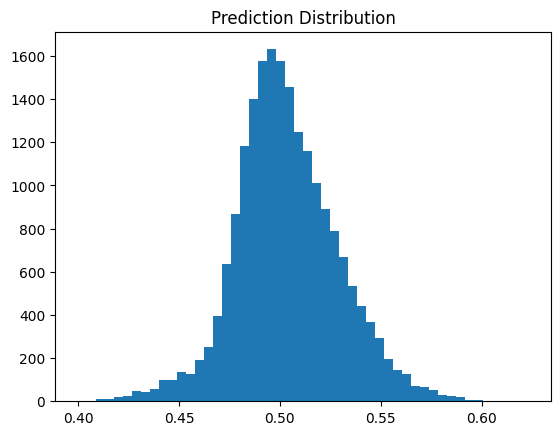

In [16]:
import matplotlib.pyplot as plt

plt.hist(y_pred, bins=50)
plt.title("Prediction Distribution")
plt.show()

In [18]:
import numpy as np

low_thresh = np.quantile(y_pred, 0.33)
high_thresh = np.quantile(y_pred, 0.66)

In [19]:
def get_risk_level(p):
    if p > high_thresh:
        return "High Risk"
    elif p > low_thresh:
        return "Moderate Risk"
    else:
        return "Low Risk"

In [20]:
risk_levels = [get_risk_level(p) for p in y_pred]

results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Risk Level": risk_levels[:10]
})

print(results)

   Actual  Predicted     Risk Level
0   0.540   0.503271  Moderate Risk
1   0.480   0.481791       Low Risk
2   0.500   0.494314  Moderate Risk
3   0.520   0.488222       Low Risk
4   0.480   0.498237  Moderate Risk
5   0.555   0.511700  Moderate Risk
6   0.535   0.504769  Moderate Risk
7   0.515   0.505268  Moderate Risk
8   0.515   0.480374       Low Risk
9   0.495   0.501584  Moderate Risk


In [21]:
import pandas as pd

# Count each risk level
risk_counts = pd.Series(risk_levels).value_counts()

print(risk_counts)

High Risk        6800
Moderate Risk    6600
Low Risk         6600
Name: count, dtype: int64


In [24]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Risk Level": risk_levels
})

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Risk Level": risk_levels
})

print(results.sample(15))

       Actual  Predicted     Risk Level
17218   0.475   0.511036  Moderate Risk
12105   0.480   0.494704  Moderate Risk
18310   0.485   0.499160  Moderate Risk
13866   0.365   0.436232       Low Risk
7475    0.475   0.489015       Low Risk
3781    0.590   0.542058      High Risk
2639    0.500   0.497346  Moderate Risk
15150   0.465   0.488202       Low Risk
17854   0.420   0.474663       Low Risk
3362    0.445   0.485220       Low Risk
7159    0.580   0.533362      High Risk
16537   0.625   0.559779      High Risk
2371    0.530   0.501089  Moderate Risk
15088   0.585   0.538329      High Risk
1483    0.570   0.543044      High Risk


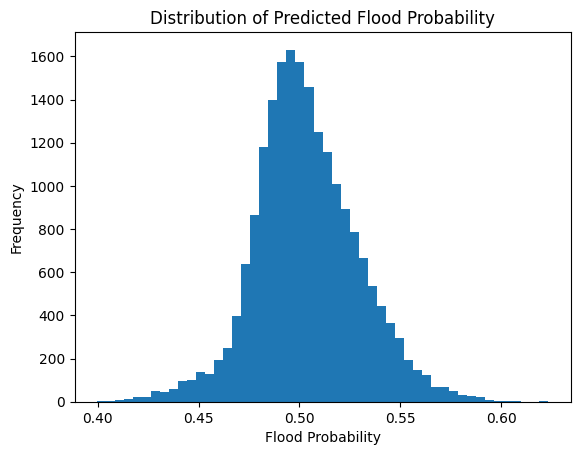

In [25]:
import matplotlib.pyplot as plt

plt.hist(y_pred, bins=50)
plt.title("Distribution of Predicted Flood Probability")
plt.xlabel("Flood Probability")
plt.ylabel("Frequency")
plt.show()

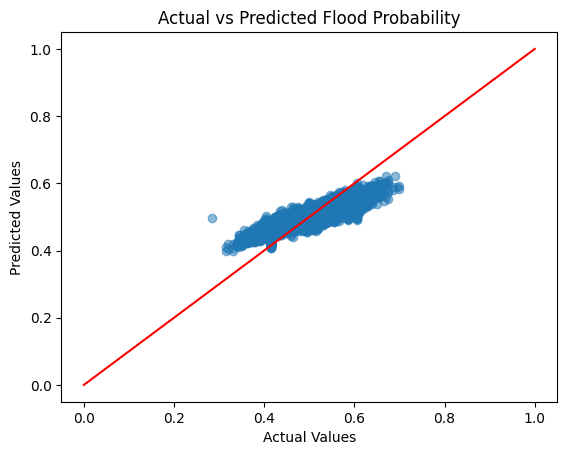

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 1], [0, 1], color='red')  # perfect prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Flood Probability")
plt.show()

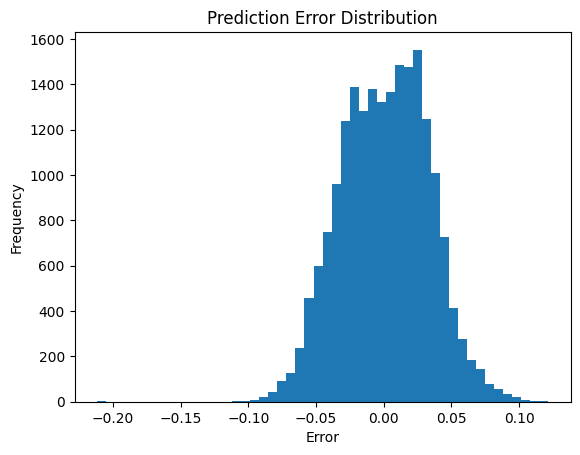

In [27]:
errors = y_test - y_pred

plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

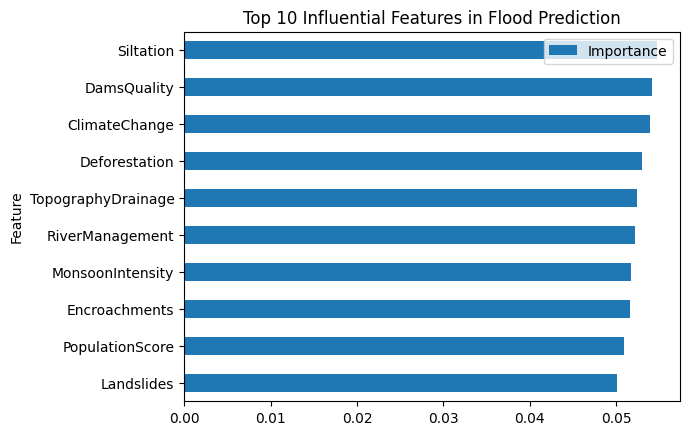

In [28]:
feat_imp_sorted = feat_imp.head(10).sort_values(by="Importance")

feat_imp_sorted.plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Influential Features in Flood Prediction")
plt.show()

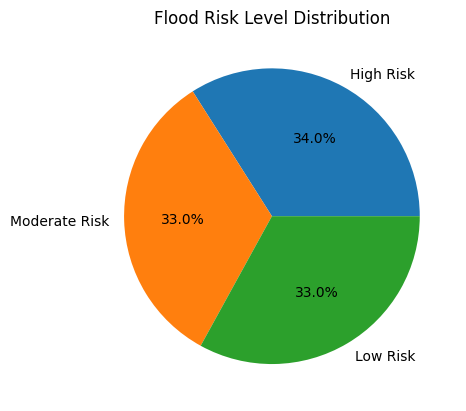

In [29]:
import pandas as pd

risk_counts = pd.Series(risk_levels).value_counts()

risk_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Flood Risk Level Distribution")
plt.ylabel("")
plt.show()

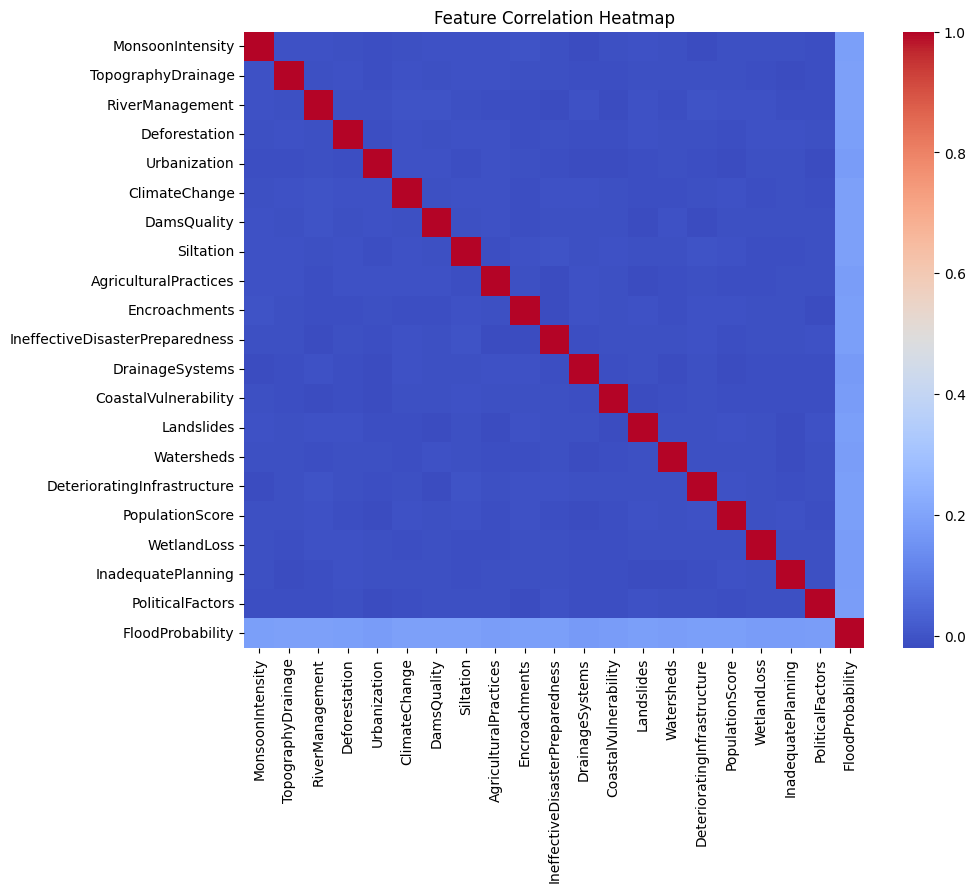

In [30]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()